In [1]:
print("Data cleaning completed successfully!")

Data cleaning completed successfully!


First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

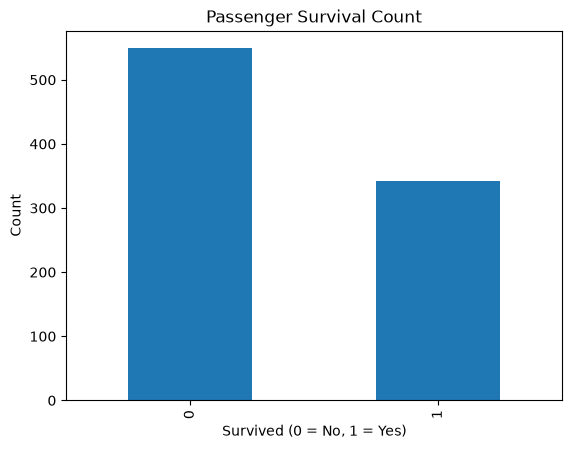

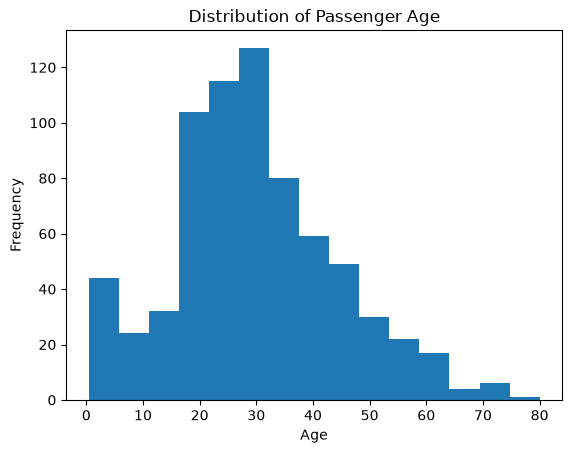

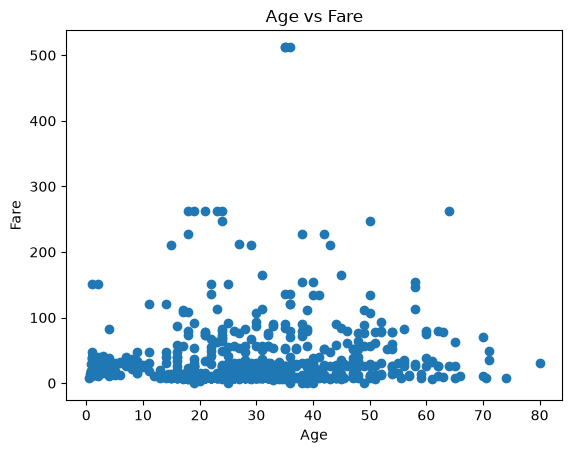

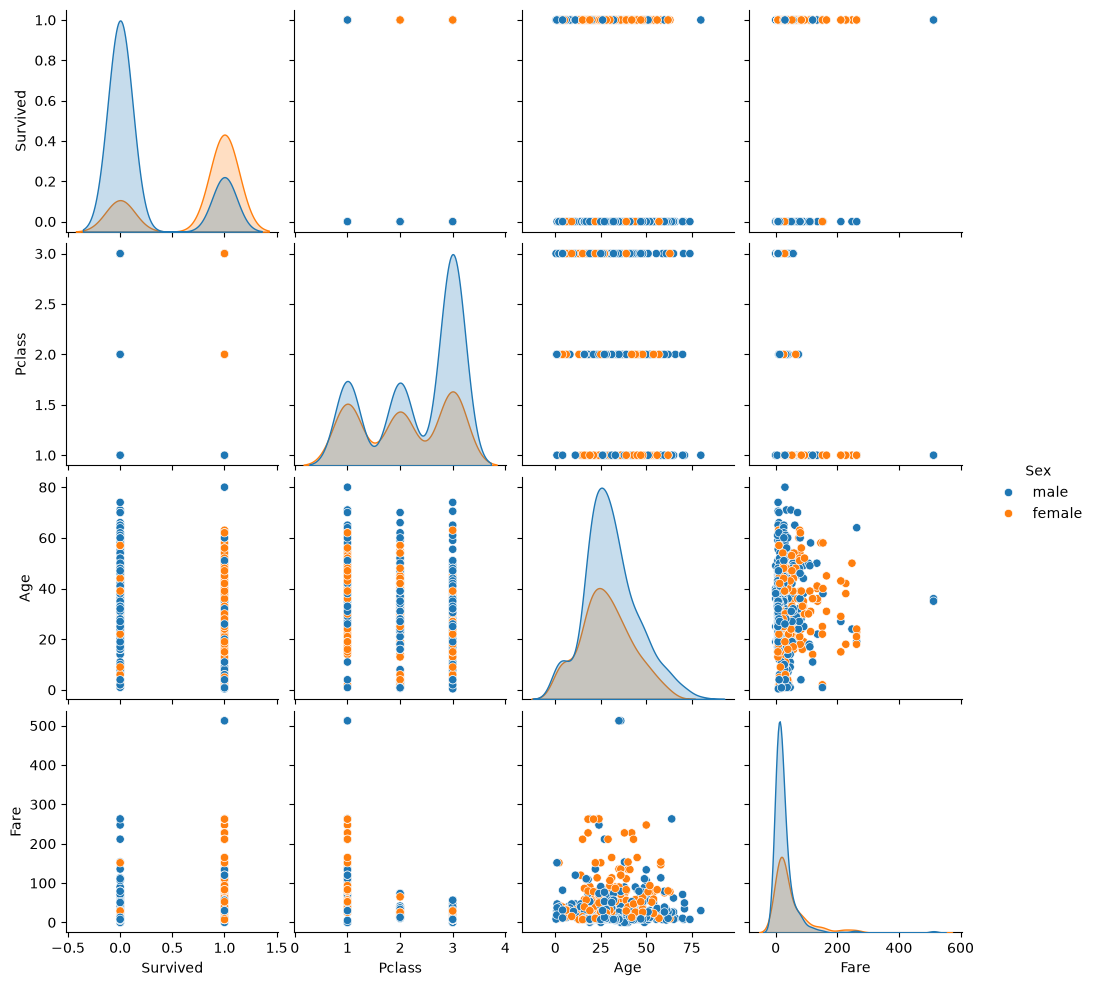


Key Insights:
- Female passengers had a higher survival rate.
- Younger passengers were more likely to survive.
- Higher-class passengers generally paid higher fares.
- First-class passengers had a better survival rate than lower classes.
- Age and Fare show a wide variation among passengers.


In [1]:
  
# TASK 2: DATA VISUALIZATION
# Titanic Dataset


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv("Titanic.csv")    

# 2. Basic Info
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

  
# 3. BAR CHART
# Passenger Survival Count
  

plt.figure()
df["Survived"].value_counts().plot(kind="bar")
plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

  
# 4. HISTOGRAM
# Age Distribution
  

plt.figure()
plt.hist(df["Age"].dropna(), bins=15)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

  
# 5. SCATTER PLOT
# Age vs Fare
  

plt.figure()
plt.scatter(df["Age"], df["Fare"])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

  
# 6. FEATURE COMPARISON (PAIRPLOT)
  

pairplot_df = df[["Survived", "Pclass", "Age", "Fare", "Sex"]].dropna()

sns.pairplot(pairplot_df, hue="Sex")
plt.show()

  
# 7. INSIGHTS
  

print("\nKey Insights:")
print("- Female passengers had a higher survival rate.")
print("- Younger passengers were more likely to survive.")
print("- Higher-class passengers generally paid higher fares.")
print("- First-class passengers had a better survival rate than lower classes.")
print("- Age and Fare show a wide variation among passengers.")

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

C:\Users\dipal\AppData\Local\Temp\ipykernel_11324\628202523.py:28: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["director"].fillna("Unknown", inplace=True)
C:\Users\dipal\AppData\Local\Temp\ipykernel_11324\628202523.py:29: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u


Content Type Distribution:
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Top Countries:
country
United States     2812
India              972
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Top Ratings:
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


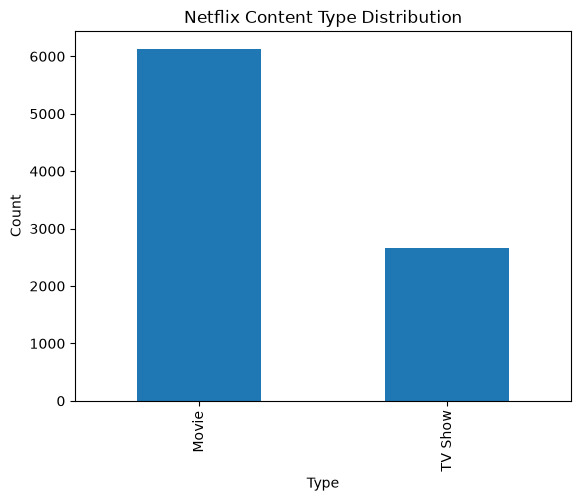

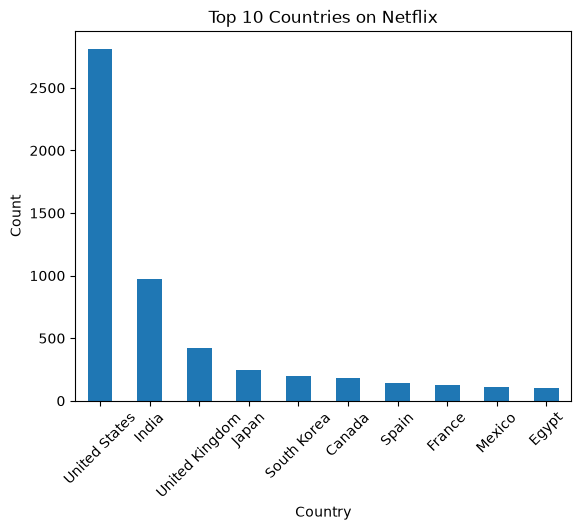

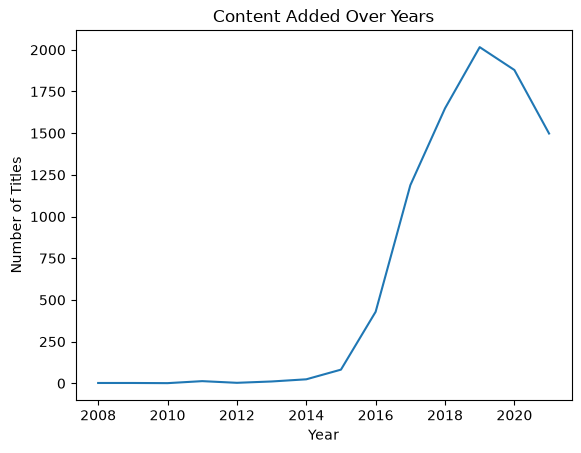

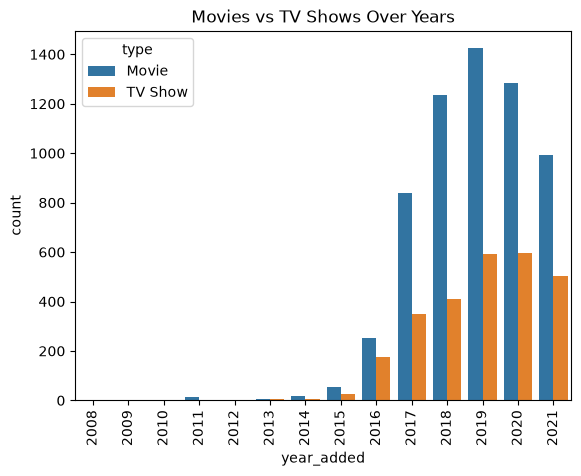

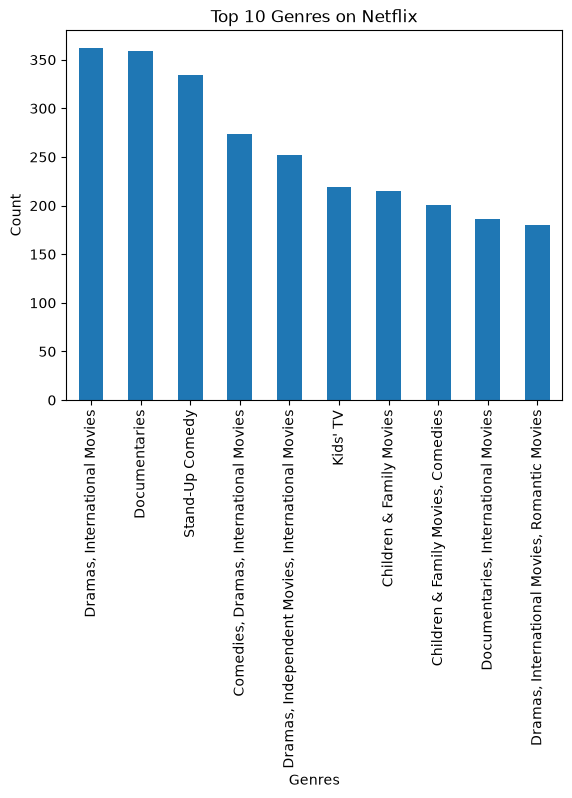

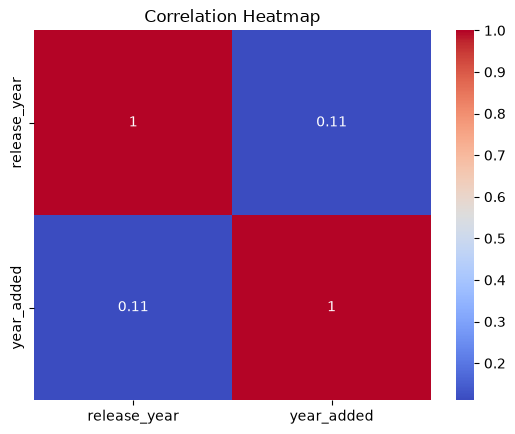


KEY INSIGHTS:
- Movies dominate over TV Shows
- Netflix added most content after 2015
- USA leads in content production
- Drama and International Movies are most common genres


In [ ]:
  
# TASK 3: EXPLORATORY DATA ANALYSIS
# Netflix Dataset
  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv("netflix_titles.csv")    

# 2. Basic Info
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

  
# 3. DATA CLEANING
  

# Fill missing values
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Unknown", inplace=True)
df["country"].fillna("Unknown", inplace=True)
df["rating"].fillna("Unknown", inplace=True)

# Drop rows with missing date_added (very few)
df.dropna(subset=["date_added"], inplace=True)

# Clean and Convert date_added to datetime, handling mixed formats
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], format='mixed', dayfirst=False)

# Extract year and month
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

  
# 4. SUMMARY STATISTICS
  

print("\nContent Type Distribution:")
print(df["type"].value_counts())

print("\nTop Countries:")
print(df["country"].value_counts().head(10))

print("\nTop Ratings:")
print(df["rating"].value_counts().head(10))

  
# 5. VISUALIZATION
  

 
# (A) Content Type Distribution
 
plt.figure()
df["type"].value_counts().plot(kind="bar")
plt.title("Netflix Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

 
# (B) Top 10 Countries
 
plt.figure()
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

 
# (C) Content Added Over Years
 
plt.figure()
df["year_added"].value_counts().sort_index().plot(kind="line")
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

 
# (D) Movies vs TV Shows Over Time
 
plt.figure()
sns.countplot(data=df, x="year_added", hue="type")
plt.xticks(rotation=90)
plt.title("Movies vs TV Shows Over Years")
plt.show()

 
# (E) Top 10 Genres
 
plt.figure()
df["listed_in"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

  
# 6. CORRELATION (basic numeric only)
  

plt.figure()
sns.heatmap(df[["release_year", "year_added"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

  
# 7. INSIGHTS
  

print("\nKEY INSIGHTS:")
print("- Movies dominate over TV Shows")
print("- Netflix added most content after 2015")
print("- USA leads in content production")
print("- Drama and International Movies are most common genres")

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     

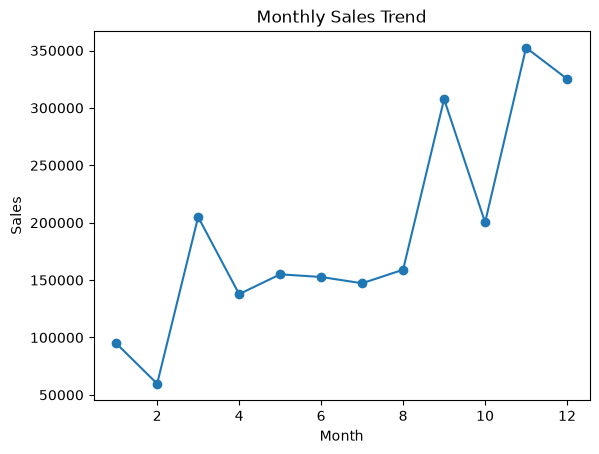

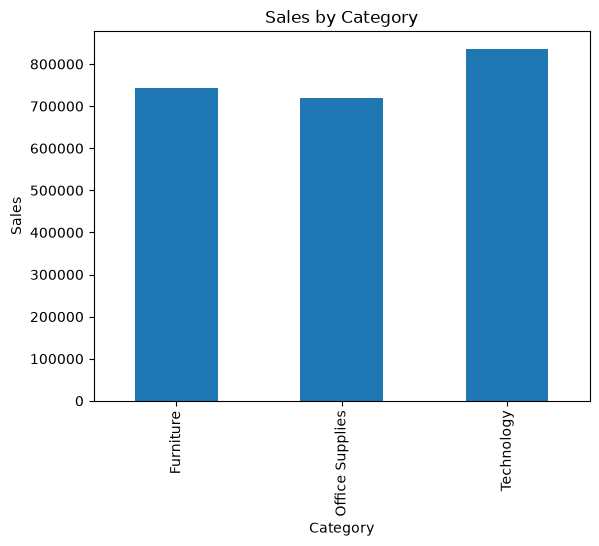

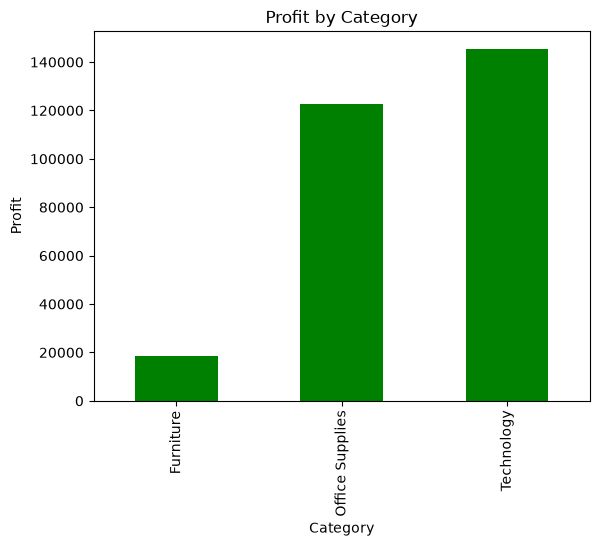

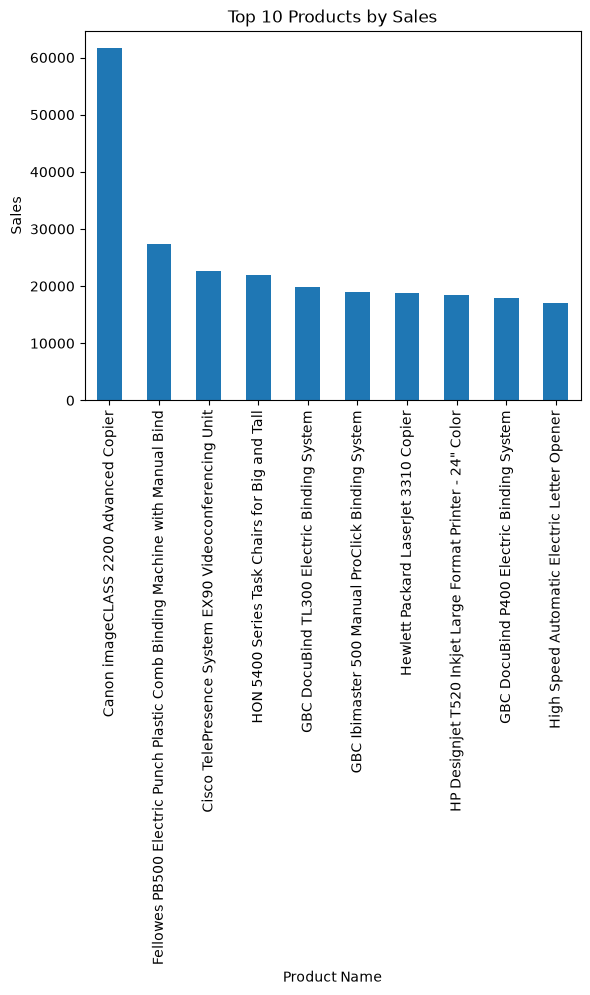

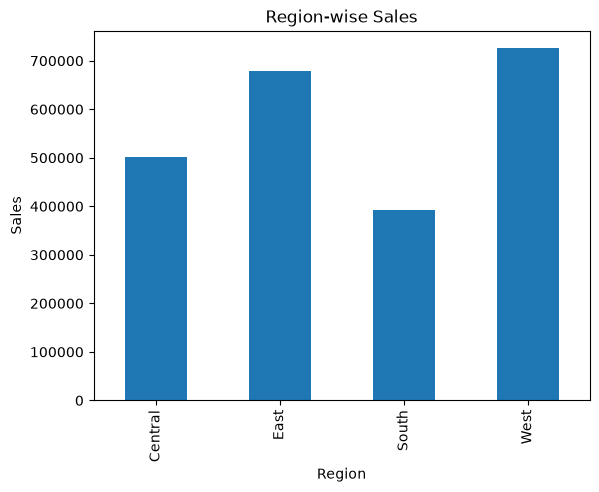

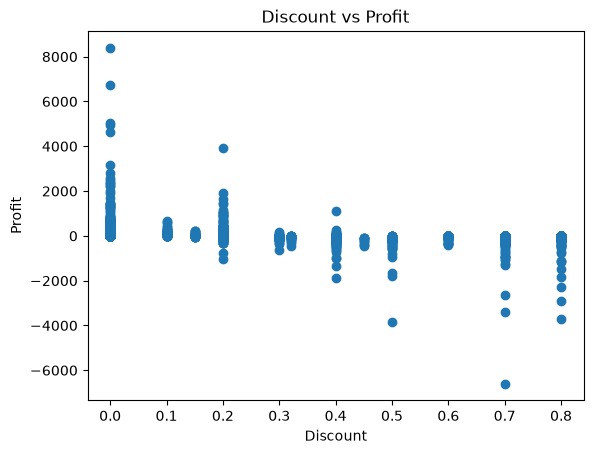

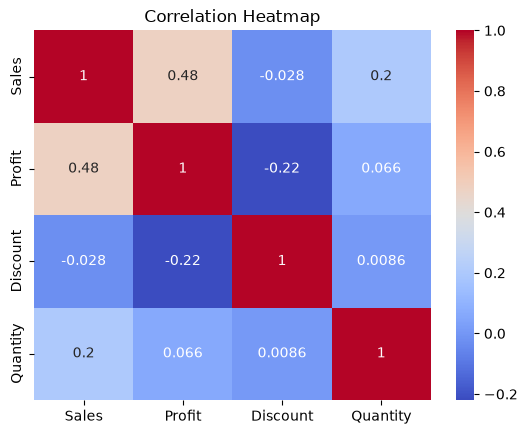


KEY INSIGHTS:
- Technology category often gives high profit
- Discounts negatively impact profit
- West region has strong sales performance
- Certain products dominate overall sales
- Sales peak varies by month showing seasonal trends


In [ ]:
  
# TASK 5: SALES DATA ANALYSIS
# Superstore Dataset
  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')    

# 2. Basic Info
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

  
# 3. DATA CLEANING
  

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Create new features
df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year

# Check duplicates
df.drop_duplicates(inplace=True)

  
# 4. SUMMARY STATISTICS
  

print("\nTotal Sales:")
print(df["Sales"].sum())

print("\nTotal Profit:")
print(df["Profit"].sum())

print("\nTop Categories:")
print(df["Category"].value_counts())

  
# 5. VISUALIZATION
  

 
# (A) Monthly Sales Trend
 
plt.figure()
df.groupby("Order Month")["Sales"].sum().plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

 
# (B) Sales by Category
 
plt.figure()
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

 
# (C) Profit by Category
 
plt.figure()
df.groupby("Category")["Profit"].sum().plot(kind="bar", color="green")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

 
# (D) Top 10 Products by Sales
 
plt.figure()
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

 
# (E) Region-wise Sales
 
plt.figure()
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

 
# (F) Discount vs Profit Relationship
 
plt.figure()
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

  
# 6. CORRELATION ANALYSIS
  

plt.figure()
sns.heatmap(df[["Sales", "Profit", "Discount", "Quantity"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

  
# 7. INSIGHTS
  

print("\nKEY INSIGHTS:")
print("- Technology category often gives high profit")
print("- Discounts negatively impact profit")
print("- West region has strong sales performance")
print("- Certain products dominate overall sales")
print("- Sales peak varies by month showing seasonal trends")

First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Missing Values:
CustomerID                0

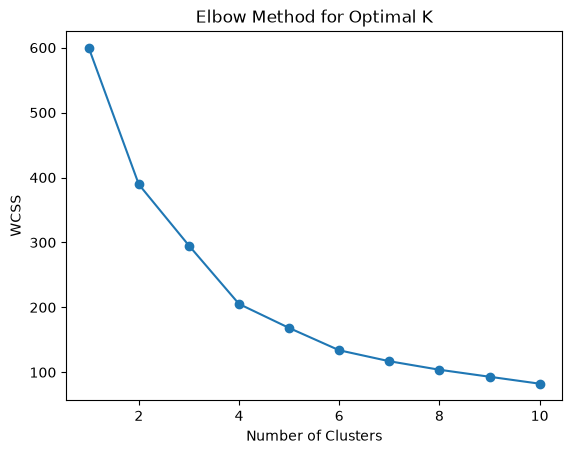

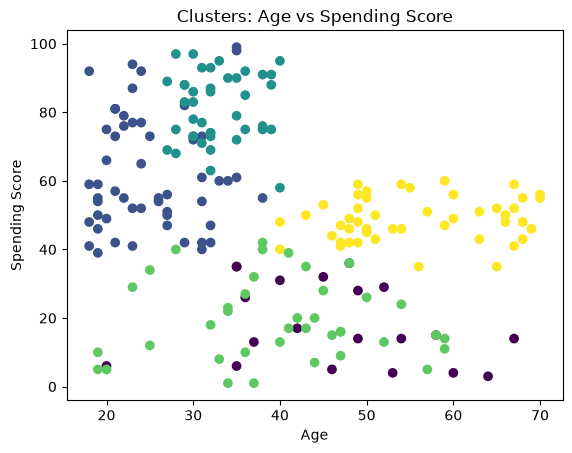

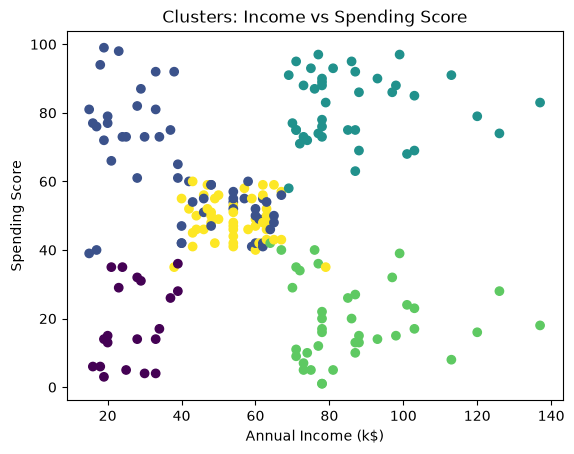


Cluster Summary:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064

KEY INSIGHTS:
- Cluster 0: Low income, low spending customers
- Cluster 1: High income, high spending customers (valuable)
- Cluster 2: Young customers with high spending
- Cluster 3: Older low-spending customers
- Cluster 4: Medium income balanced customers


In [ ]:
  
# TASK 6: CUSTOMER SEGMENTATION
# K-Means Clustering
# Mall Customer Dataset
  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans

# 1. Load Dataset
df = pd.read_csv("Mall_Customers.csv")    

# 2. Basic Info
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

  
# 3. DATA PREPROCESSING
  

# Encode Gender column
le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"])  # Male=1, Female=0 (or vice versa)

# Select features for clustering
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

# Standardize features (VERY IMPORTANT for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

  
# 4. FIND OPTIMAL CLUSTERS (ELBOW METHOD)
  

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

  
# 5. APPLY K-MEANS MODEL
  

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

  
# 6. VISUALIZATION OF CLUSTERS
  

# (A) Age vs Spending Score
plt.figure()
plt.scatter(df["Age"], df["Spending Score (1-100)"], c=df["Cluster"], cmap="viridis")
plt.title("Clusters: Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.show()

# (B) Income vs Spending Score
plt.figure()
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=df["Cluster"], cmap="viridis")
plt.title("Clusters: Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

  
# 7. CLUSTER ANALYSIS
  

print("\nCluster Summary:")
print(df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean())

  
# 8. INSIGHTS
  

print("\nKEY INSIGHTS:")
print("- Cluster 0: Low income, low spending customers")
print("- Cluster 1: High income, high spending customers (valuable)")
print("- Cluster 2: Young customers with high spending")
print("- Cluster 3: Older low-spending customers")
print("- Cluster 4: Medium income balanced customers")